# IMLO_Open Assesment
Y3921738

## Initialisation

### Imports 

In [1]:
import torch
from torch import nn
# import torch.nn.functional as F 
from torch.utils.data import DataLoader
import torch.optim.lr_scheduler as Scheduler
from torchvision import datasets
import torchvision.transforms as transforms
from torch.utils.data import ConcatDataset
import torchvision.models as models
import matplotlib.pyplot as plt
 

### Hyper Parameters

In [2]:
image_size = 227 #227 for alex
batch_size = 4
epochs = 100
learning_rate = 1e-4

sgd_momentum = 0.9
sgd_weight_decay = 1e-4
sgd_dampening = 0

adam_decay = 1e-3

drop_out = 0.5

patience = 3
factor = 0.5
threshold = 1e-1
threshold_mode = "abs"
cooldown = 5

device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

save_path = "./flowers-102.pth"

## Data Preprocessing

In [3]:
test_transform = transforms.Compose([
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=45),  # Randomly rotate the image by up to 15 degrees
    transforms.RandomHorizontalFlip(),      # Randomly flip the image horizontally with a probability of 0.5
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.3),  # Randomly adjust brightness, contrast, saturation, and hue
    transforms.Resize(size=(image_size, image_size)),
    transforms.ToTensor(),  # Convert the image to a PyTorch tensor
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # Normalize the image using ImageNet statistics
])

validation_data = datasets.Flowers102(root="data", split="val", transform=test_transform, download=True)
test_data = datasets.Flowers102(root="data", split="test", transform=test_transform, download=True)

training_data = datasets.Flowers102(root="data", split="train", transform=test_transform, download=True)
for i in range(2):
    augmented = datasets.Flowers102(root="data", split="train", transform=train_transform)
    training_data = ConcatDataset([training_data, augmented])

train_dataloader = DataLoader(training_data, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=batch_size)
validation_dataloader = DataLoader(validation_data, batch_size=batch_size)

## Neural Network

### Base Network Class

In [4]:
class ConvNetwork(nn.Module):
    """
    A class that represents a convolutional neural network.
    ...
    Methods:
        forward (x): Takes the input x and computes the output from the network
    """
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.conv_stack = nn.Sequential(
            # Conv layer 1
            nn.Conv2d(3, 6, 5),
            nn.BatchNorm2d(6),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            # Conv layer 2
            nn.Conv2d(6, 16, 5),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.linear_relu_stack = nn.Sequential(
            # Linear layer 1
            nn.Linear(44944, 512), # image size -12 squared, for the conv and pool (image_size - 12)*(image_size - 12)
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(drop_out),
            # Linear layer 2
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(drop_out),
            # Out layer
            nn.Linear(512, 102)
        )

    def forward(self, x):
        """
        Takes input x and returns the output of the network
        ...
        Parameters:
            x (Torch Tensor): the input
        Returns:
            x (Torch Tensor): output of network
        """
        x = self.conv_stack(x)
        x = self.flatten(x)
        out = self.linear_relu_stack(x)
        return out


### Extra convolutional layers

In [5]:
class ConvNetworkExtraConv(nn.Module):
    """
    A class that represents a convolutional neural network.
    ...
    Methods:
        forward (x): Takes the input x and computes the output from the network
    """
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        conv_output_size = image_size // 16  # assuming image_size is divisible by 16
        flattened_size = conv_output_size * conv_output_size * 256  # 256 is the number of filters in the last conv layer
        self.conv_stack = nn.Sequential(
            # Conv layer 1
            nn.Conv2d(3, 32, 5, padding=2),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # half dimensions
            # Conv layer 2
            nn.Conv2d(32, 64, 5, padding=2),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # half dimensions

            # Conv layer 3
            nn.Conv2d(64, 128, 5, padding=2),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # half dimensions
            # Conv layer 4
            nn.Conv2d(128, 256, 5, padding=2),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2), # half dimensions
        )
    
        self.linear_relu_stack = nn.Sequential(
            # Linear layer 1
            nn.Linear(flattened_size, 512), # image size -12 squared, for the conv and pool (image_size - 12)*(image_size - 12)
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(drop_out),
            # Linear layer 2
            # nn.Linear(512, 512),
            # nn.BatchNorm1d(512),
            # nn.ReLU(),
            # nn.Dropout(drop_out),
            # Out layer
            nn.Linear(512, 102)
        )

    def forward(self, x):
        """
        Takes input x and returns the output of the network
        ...
        Parameters:
            x (Torch Tensor): the input
        Returns:
            x (Torch Tensor): output of network
        """
        x = self.conv_stack(x)
        x = self.flatten(x)
        out = self.linear_relu_stack(x)
        return out


### Network 3 Vgg Inspired

In [6]:
class VGGstyleNetwork(nn.Module):
    """
    A class that represents a VGG11 neural network.
    ...
    Methods:
        forward (x): Takes the input x and computes the output from the network
    """
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        conv_output_size = image_size // 16 
        flattened_size = 8192  
        kernel_size = 5
        padding = (kernel_size-1)//2
        self.conv_stack = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 64, kernel_size=kernel_size, padding=padding, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            # Conv Block 2
            nn.Conv2d(64, 128, kernel_size=kernel_size, padding=padding, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            # Conv Block 3
            nn.Conv2d(128, 256, kernel_size=kernel_size, padding=padding, stride=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=kernel_size, padding=padding, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            # Conv Block 4
            nn.Conv2d(256, 512, kernel_size=kernel_size, padding=padding, stride=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=kernel_size, padding=padding, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            
            # Conv Block 5
            nn.Conv2d(512, 512, kernel_size=kernel_size, padding=1, stride=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=kernel_size, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
    
        self.linear_relu_stack = nn.Sequential(
            # Linear layer 1
            nn.Linear(flattened_size, 512), # image size -12 squared, for the conv and pool (image_size - 12)*(image_size - 12)
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(drop_out),
            # Linear layer 2
            nn.Linear(512, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(drop_out),
            # Out layer
            nn.Linear(512, 102)
        )

    def forward(self, x):
        """
        Takes input x and returns the output of the network
        ...
        Parameters:
            x (Torch Tensor): the input
        Returns:
            x (Torch Tensor): output of network
        """
        x = self.conv_stack(x)
        x = self.flatten(x)
        out = self.linear_relu_stack(x)
        return out

### AlexNet Inspired

In [7]:
class AlexStyleNetwork(nn.Module):
    """
    A class that represents a VGG11 neural network.
    ...
    Methods:
        forward (x): Takes the input x and computes the output from the network
    """
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        flattened_size = 9216 
        self.conv_stack = nn.Sequential(
            # Conv Block 1
            nn.Conv2d(3, 96, kernel_size=11, padding=5, stride=4),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.ReLU(),
            
            # Conv Block 2
            nn.Conv2d(96, 256, kernel_size=5, padding=2, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.ReLU(),
            
            # Conv Block 3
            nn.Conv2d(256, 384, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.Conv2d(384, 384, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.Conv2d(384, 256, kernel_size=3, padding=1, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.ReLU()
        )
    
        self.linear_relu_stack = nn.Sequential(
            # Linear layer 1
            nn.Linear(flattened_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(drop_out),
            # Linear layer 2
            # nn.Linear(1024, 1024),
            # nn.BatchNorm1d(1024),
            # nn.ReLU(),
            # nn.Dropout(drop_out),
            # Out layer
            nn.Linear(512, 102)
        )

    def forward(self, x):
        """
        Takes input x and returns the output of the network
        ...
        Parameters:
            x (Torch Tensor): the input
        Returns:
            x (Torch Tensor): output of network
        """
        x = self.conv_stack(x)
        x = self.flatten(x)
        out = self.linear_relu_stack(x)
        return out

### Generate Instance

In [8]:
classifier = AlexStyleNetwork().to(device)
# classifier.load_state_dict(torch.load(save_path)) # This is optional and lets us load a saved model we have trained before
# print(classifier)

# Training

### Training Parameters

In [9]:
loss_fn = nn.CrossEntropyLoss()

# still look at new optimisers
optimizer1 = torch.optim.SGD(classifier.parameters(), lr=learning_rate, momentum=sgd_momentum, dampening=sgd_dampening, weight_decay=sgd_weight_decay)
optimizer2 = torch.optim.Adam(classifier.parameters(), lr=learning_rate, weight_decay=adam_decay)
optimizer = optimizer1

scheduler = Scheduler.ReduceLROnPlateau(optimizer=optimizer, patience=patience, factor=factor, threshold=threshold, threshold_mode=threshold_mode, cooldown=cooldown)

### Training, Validation and Testing Loops

In [10]:
def train_loop(dataloader, classifier, loss_fn, optimizer):
    losses = 0
    classifier.train()
    batches_ran = 0
    size = len(dataloader.dataset)
    
    for batch, (X, y) in enumerate(dataloader):
        y_pred = classifier(X.to(device))
        loss = loss_fn(y_pred, y.to(device))
        losses += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        batches_ran += 1
        if batch % ((size/batch_size)//100) == 0:
            print(end="|")
    avg_loss = losses/batches_ran
    print()
    return avg_loss

# This can also act as the loop for testing if we load the testing data loader
def validation_loop(dataloader, classifier, loss_fn):
    classifier.eval()
    size = len(dataloader.dataset)
    loss = 0
    accuracy = 0

    with torch.no_grad():
        for (X, y) in dataloader:
            y_pred = classifier(X.to(device))
            loss += loss_fn(y_pred, y.to(device)).item()
            accuracy += (y_pred.argmax(1) == y.to(device)).type(torch.float).sum().item()

    loss /= len(dataloader)
    accuracy = (accuracy / size) * 100
    return accuracy, loss


### Run Classifier on Training and Validation Data

In [11]:
train_losses, val_accuracies, val_losses = [], [], []
print(f"Using {device} device")
for i in range(epochs):
    print(f"Epoch {i+1}:",  end="")
    train_loss = train_loop(train_dataloader, classifier, loss_fn, optimizer)
    val_accuracy, val_loss = validation_loop(validation_dataloader, classifier, loss_fn)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_accuracies.append(val_accuracy)
    val_losses.append(val_loss)
    print(f"Training Avg Loss: {train_loss:>8f} | Validation Avg Loss: {val_loss:>8f} | Validation Accuracy: {(val_accuracy):>0.3f}% | Learning rate: {scheduler.get_last_lr()}")
    torch.cuda.synchronize()
print("Finished Training")

Using cuda device
Epoch 1:

c:\Users\elija\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\nn\modules\conv.py:456: UserWarning: Plan failed with a cudnnException: CUDNN_BACKEND_EXECUTION_PLAN_DESCRIPTOR: cudnnFinalize Descriptor Failed cudnn_status: CUDNN_STATUS_NOT_SUPPORTED (Triggered internally at ..\aten\src\ATen\native\cudnn\Conv_v8.cpp:919.)
  return F.conv2d(input, weight, bias, self.stride,


||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Training Avg Loss: 4.540988 | Validation Avg Loss: 4.139210 | Validation Accuracy: 7.647% | Learning rate: [0.0001]
Epoch 2:||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Training Avg Loss: 4.231600 | Validation Avg Loss: 3.866096 | Validation Accuracy: 10.588% | Learning rate: [0.0001]
Epoch 3:||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Training Avg Loss: 4.054970 | Validation Avg Loss: 3.651477 | Validation Accuracy: 16.765% | Learning rate: [0.0001]
Epoch 4:||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Training Avg Loss: 3.867091 | Validation Avg Loss: 3.535443 | Validation Accuracy: 18.529% | Learning rate: [0.0001]
Epoch 5:|||||||||||||||||||||||||||||||||||||||||||||||||||||||||

KeyboardInterrupt: 

# Testing And Evaluation

### Testing Data

In [ ]:
print("Testing:")
test_accuracy, test_loss = validation_loop(test_dataloader, classifier, loss_fn)
print(f"Loss: {test_loss} | Accuracy: {test_accuracy}")

Testing:
Loss: 2.1298803270315165 | Accuracy: 50.349650349650354


### Graph Data

Highest Accuracy: 3.73


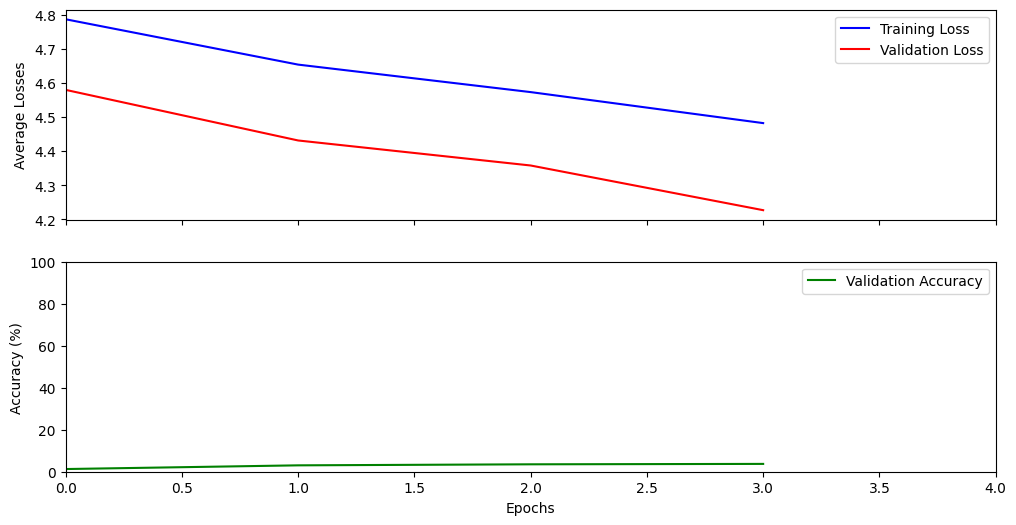

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, figsize=(12,6), sharex=True)
ax1.plot(range(len(train_losses)), train_losses, color="blue", label="Training Loss")
ax1.plot(range(len(val_losses)), val_losses, color="red", label="Validation Loss")
ax1.set(ylabel='Average Losses')
ax1.legend()
ax2.axis([0, len(val_accuracies), 0, 100])
ax2.plot(range(len(val_accuracies)), val_accuracies, color="green", label="Validation Accuracy")
ax2.set(xlabel='Epochs', ylabel='Accuracy (%)')
ax2.legend()
print(f"Highest Accuracy: {(max(val_accuracies)):>0.2f}")

# Save the model

In [ ]:
model = models.vgg16(weights='IMAGENET1K_V1')
torch.save(model.state_dict(), save_path)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\elija/.cache\torch\hub\checkpoints\vgg16-397923af.pth
100%|██████████| 528M/528M [00:26<00:00, 20.6MB/s] 
